# OpenFAST DLC 1.1 Post-Processing

This notebook presents the post-processing workflow for the OpenFAST DLC 1.1 load simulations of the NREL 5-MW reference wind turbine.

### Contents

1. Load and Organize OpenFAST Simulation Outputs
2. Extract Case-Wise Load Statistics
3. Generate Extreme-Load Matrix
4. Extract Maximum Loads by Wind Speed
5. Generate Load Envelopes
6. Statistical Extreme-Load Analysis
7. Compare Simulated and Statistical Load Envelopes


## 1. Load and Organize OpenFAST Simulation Outputs

Import OpenFAST output files and organize the simulation results by wind speed and turbulence seed.
> **Note:** `WS23_Seed02` was excluded from the analysis due to a fatal OpenFAST error caused by a tower strike.


In [58]:
from pathlib import Path
import pandas as pd
from openfast_toolbox.io import FASTOutputFile
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

OUT_DIR = Path("FAST files") / "OpenFAST_Case_Outputs"

# Wind speed [m/s] : number of turbulence seeds
WIND_CASES = {
    5: 3,
    7: 3,
    9: 3,
    11: 6,
    13: 6,
    15: 6,
    19: 6,
    23: 6,
}

# Store one DataFrame per simulation case
cases = {}

# Generate the expected OpenFAST output-file path for each case

def get_outb_file(out_dir: Path, wind_speed: int, seed: int) -> Path:

    filename = (
        f"5MW_Land_DLL_WTurb_WS{wind_speed:02d}_Seed{seed:02d}.outb"
    )

    return (
        out_dir
        / f"WS{wind_speed:02d}"
        / f"Seed{seed:02d}"
        / filename
    )


# ============================================================
# READ OPENFAST OUTPUTS
# ============================================================


# Read an OpenFAST output file and store it as a DataFrame
def create_case_df(outb_file: Path, wind_speed: int, seed: int):

    case_name = f"WS{wind_speed:02d}_Seed{seed:02d}"

    out = FASTOutputFile(str(outb_file))
    df = out.toDataFrame()

    cases[case_name] = df


# Load all available simulation cases
for wind_speed, number_of_seeds in WIND_CASES.items():

    for seed in range(1, number_of_seeds + 1):

        out_file = get_outb_file(
            OUT_DIR,
            wind_speed,
            seed
        )

        if out_file.exists():
            create_case_df(
                out_file,
                wind_speed,
                seed
            )

# example
cases["WS23_Seed01"]


,Time_[s],ConvIter_[-],ConvError_[-],NumUJac_[-],Wind1VelX_[m/s],Wind1VelY_[m/s],Wind1VelZ_[m/s],OoPDefl1_[m],IPDefl1_[m],TwstDefl1_[deg],...,YawBrMyp_[kN-m],YawBrMzp_[kN-m],TwrBsFxt_[kN],TwrBsFyt_[kN],TwrBsFzt_[kN],TwrBsMxt_[kN-m],TwrBsMyt_[kN-m],TwrBsMzt_[kN-m],GenPwr_[kW],GenTq_[kN-m]
0,0.00000,0.0,0.000000,1.0,21.224371,1.174825,-1.002243,0.000000,-0.000000,0.0,...,-338.148804,0.000574,0.498737,-0.539028,-6743.992188,19.916740,-152.944168,0.000574,5000.000000,43.093544
1,0.00625,2.0,0.000027,1.0,21.205681,1.241401,-1.001328,0.001619,-0.000177,0.0,...,-349.318207,-0.001892,0.320574,-1.361179,-6744.190918,33.726013,-154.220184,-0.000820,5000.000000,43.093544
2,0.01250,2.0,0.000085,0.0,21.186995,1.307976,-1.000413,0.008079,-0.000893,0.0,...,-361.052490,1.369987,0.697926,-3.286334,-6744.528809,67.047745,-139.185349,1.370121,4969.718262,43.096123
3,0.01875,3.0,0.000003,0.0,21.168308,1.374551,-0.999499,0.020949,-0.002353,0.0,...,-377.462585,4.289542,1.611927,-5.895896,-6745.139160,111.794312,-108.062157,4.290453,4940.215332,43.101204
4,0.02500,3.0,0.000002,0.0,21.149624,1.441127,-0.998584,0.040140,-0.004604,0.0,...,-395.148804,7.496732,3.156074,-9.081691,-6746.082520,165.468460,-58.536842,7.497568,4931.887695,43.107002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95996,599.97500,3.0,0.000010,0.0,21.196499,1.019895,-0.567387,1.523910,-1.053348,0.0,...,1720.130859,33.110771,161.860062,113.062386,-6858.703613,-2734.013184,19566.998047,34.467644,5007.871582,43.664825
95997,599.98125,3.0,0.000009,0.0,21.174770,1.076651,-0.534010,1.491739,-1.040617,0.0,...,1714.769287,34.259792,161.691956,104.183685,-6858.349609,-2514.901855,19565.751953,35.612724,5006.675293,43.664249
95998,599.98750,3.0,0.000008,0.0,21.153038,1.133407,-0.500632,1.459041,-1.027866,0.0,...,1704.114502,39.831505,162.755890,94.790298,-6858.022461,-2281.408203,19599.828125,41.181347,5005.443848,43.663784
95999,599.99375,3.0,0.000010,0.0,21.131140,1.190606,-0.466993,1.425880,-1.015105,0.0,...,1688.745483,49.097652,165.060806,85.010361,-6857.728027,-2036.991089,19669.320312,50.444885,5004.179199,43.663422


## OpenFAST Output Channels

| # | Channel | Description |
|---:|---|---|
| 1 | `Time_[s]` | Simulation time in seconds. |
| 2 | `ConvIter_[-]` | Number of iterations performed by the OpenFAST nonlinear solver during the current time step. |
| 3 | `ConvError_[-]` | Convergence error of the OpenFAST nonlinear solver during the current time step. |
| 4 | `NumUJac_[-]` | Number of times the Jacobian matrix was updated during the current time step. |
| 5 | `Wind1VelX_[m/s]` | Wind velocity component in the inertial/global X direction at wind output point 1. |
| 6 | `Wind1VelY_[m/s]` | Wind velocity component in the inertial/global Y direction at wind output point 1. |
| 7 | `Wind1VelZ_[m/s]` | Wind velocity component in the inertial/global Z direction at wind output point 1. |
| 8 | `OoPDefl1_[m]` | Out-of-plane deflection of blade 1 at the blade tip, in metres. |
| 9 | `IPDefl1_[m]` | In-plane deflection of blade 1 at the blade tip, in metres. |
| 10 | `TwstDefl1_[deg]` | Blade 1 tip twist deflection, in degrees. |
| 11 | `BldPitch1_[deg]` | Pitch angle of blade 1, in degrees. |
| 12 | `Azimuth_[deg]` | Rotor azimuth angle, describing the angular position of blade 1 relative to the defined azimuth reference, in degrees. |
| 13 | `RotSpeed_[rpm]` | Rotor rotational speed, in revolutions per minute. |
| 14 | `GenSpeed_[rpm]` | Generator rotational speed, in revolutions per minute. |
| 15 | `TTDspFA_[m]` | Tower-top fore-aft displacement, in metres. |
| 16 | `TTDspSS_[m]` | Tower-top side-to-side displacement, in metres. |
| 17 | `TTDspTwst_[deg]` | Tower-top torsional rotation about the tower vertical axis, in degrees. |
| 18 | `Spn2MLxb1_[kN-m]` | Blade 1 sectional moment about the blade local x-axis at span station 2, in kN·m. |
| 19 | `Spn2MLyb1_[kN-m]` | Blade 1 sectional moment about the blade local y-axis at span station 2, in kN·m. |
| 20 | `RootFxb1_[kN]` | Blade 1 root force in the blade local x-direction, in kN. |
| 21 | `RootFyb1_[kN]` | Blade 1 root force in the blade local y-direction, in kN. |
| 22 | `RootFzb1_[kN]` | Blade 1 root force in the blade local z-direction, in kN. |
| 23 | `RootMxb1_[kN-m]` | Blade 1 root moment about the blade local x-axis, in kN·m. |
| 24 | `RootMyb1_[kN-m]` | Blade 1 root moment about the blade local y-axis, in kN·m. |
| 25 | `RootMzb1_[kN-m]` | Blade 1 root moment about the blade local z-axis, in kN·m. |
| 26 | `RotTorq_[kN-m]` | Rotor aerodynamic torque about the rotor shaft, in kN·m. |
| 27 | `LSSGagMya_[kN-m]` | Low-speed shaft gauge moment about the shaft y-axis, in kN·m. |
| 28 | `LSSGagMza_[kN-m]` | Low-speed shaft gauge moment about the shaft z-axis, in kN·m. |
| 29 | `YawBrFxp_[kN]` | Yaw-bearing force in the platform/inertial x-direction, in kN. |
| 30 | `YawBrFyp_[kN]` | Yaw-bearing force in the platform/inertial y-direction, in kN. |
| 31 | `YawBrFzp_[kN]` | Yaw-bearing force in the platform/inertial z-direction, in kN. |
| 32 | `YawBrMxp_[kN-m]` | Yaw-bearing moment about the platform/inertial x-axis, in kN·m. |
| 33 | `YawBrMyp_[kN-m]` | Yaw-bearing moment about the platform/inertial y-axis, in kN·m. |
| 34 | `YawBrMzp_[kN-m]` | Yaw-bearing moment about the platform/inertial z-axis, in kN·m. |
| 35 | `TwrBsFxt_[kN]` | Tower-base force in the tower x-direction, in kN. |
| 36 | `TwrBsFyt_[kN]` | Tower-base force in the tower y-direction, in kN. |
| 37 | `TwrBsFzt_[kN]` | Tower-base force in the tower z-direction, in kN. |
| 38 | `TwrBsMxt_[kN-m]` | Tower-base moment about the tower x-axis, in kN·m. |
| 39 | `TwrBsMyt_[kN-m]` | Tower-base moment about the tower y-axis, in kN·m. |
| 40 | `TwrBsMzt_[kN-m]` | Tower-base moment about the tower z-axis, in kN·m. |
| 41 | `GenPwr_[kW]` | Generator electrical power, in kW. |
| 42 | `GenTq_[kN-m]` | Generator torque, in kN·m. |


## 2. Extract Case-Wise Load Statistics

Calculate maximum, minimum, absolute maximum, mean, standard deviation, and RMS for each simulation case.


In [59]:
# ============================================================
# EXTRACT CASE EXTREMES & STATISTICS
# ============================================================

case_statistics = {}

for case_name, df in cases.items():

    case_statistics[case_name] = pd.DataFrame({
        "Maximum": df.max(),
        "Minimum": df.min(),
        "Absolute Maximum": df.abs().max(),
        "Mean": df.mean(),
        "Std": df.std(),
        "RMS": (df ** 2).mean() ** 0.5
    })
    
# example
case_statistics["WS23_Seed03"]


,Maximum,Minimum,Absolute Maximum,Mean,Std,RMS
Time_[s],600.000000,0.000000,600.000000,300.000000,173.207787,346.411064
ConvIter_[-],4.000000,0.000000,4.000000,3.010719,0.103681,3.012503
ConvError_[-],0.000100,0.000000,0.000100,0.000021,0.000020,0.000029
NumUJac_[-],1.000000,0.000000,1.000000,0.000021,0.004564,0.004564
Wind1VelX_[m/s],32.618729,11.948026,32.618729,22.983575,3.278112,23.216171
Wind1VelY_[m/s],10.036029,-8.922581,10.036029,0.081954,2.513978,2.515300
Wind1VelZ_[m/s],5.074653,-6.623704,6.623704,0.002087,1.525068,1.525061
OoPDefl1_[m],10.399652,-3.906113,10.399652,0.659762,1.164190,1.338137
IPDefl1_[m],2.440219,-2.290217,2.440219,-0.257198,0.658977,0.707387
TwstDefl1_[deg],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 3. Generate Extreme-Load Matrix

Organize the case-wise maximum loads into a matrix for comparison across simulation cases.


In [60]:
# ============================================================
# EXTREME-LOAD MATRIX
# ============================================================

# Rows    → channels
# Columns → simulation cases
# Values  → case maximum
max_df = pd.DataFrame({
    case: stats["Maximum"]
    for case, stats in case_statistics.items()
})

max_df

,WS05_Seed01,WS05_Seed02,WS05_Seed03,WS07_Seed01,WS07_Seed02,WS07_Seed03,WS09_Seed01,WS09_Seed02,WS09_Seed03,WS11_Seed01,...,WS19_Seed02,WS19_Seed03,WS19_Seed04,WS19_Seed05,WS19_Seed06,WS23_Seed01,WS23_Seed03,WS23_Seed04,WS23_Seed05,WS23_Seed06
Time_[s],600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,...,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
ConvIter_[-],4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
ConvError_[-],0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,...,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100
NumUJac_[-],1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Wind1VelX_[m/s],8.348792,8.465459,8.449757,11.121075,11.126370,11.241893,13.891159,13.695979,13.938906,16.857260,...,27.693623,27.361950,27.118046,26.130289,28.166327,34.178963,32.618729,32.024456,31.225746,33.901154
Wind1VelY_[m/s],3.046153,3.040268,3.992340,3.632034,3.572845,4.692206,4.224545,4.138034,5.380169,4.796032,...,7.394865,8.705250,7.454849,6.959748,6.494424,8.251671,10.036029,8.634080,8.155157,7.548657
Wind1VelZ_[m/s],2.019215,1.912955,2.179533,2.471718,2.231731,2.503249,2.922929,2.615999,2.827346,3.361511,...,4.433709,4.412346,4.577727,5.039797,4.597652,6.051541,5.074653,5.255431,5.889032,5.203844
OoPDefl1_[m],3.150570,3.409810,2.851326,4.324804,4.807630,4.181512,6.254191,6.566038,5.881485,6.848869,...,8.215910,8.853499,9.621452,8.857288,8.721299,9.742605,10.399652,10.920349,10.578427,9.884286
IPDefl1_[m],0.389897,0.440351,0.410591,0.362536,0.411432,0.369059,0.302383,0.358306,0.322414,0.250440,...,0.958798,1.364294,1.152921,1.133284,1.183525,1.669445,2.440219,1.661238,2.050466,1.927525
TwstDefl1_[deg],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 4. Extract Maximum Loads by Wind Speed

Group simulation cases by wind speed and identify the maximum load across all turbulence seeds.

In [61]:
# Group cases by wind speed and take the maximum across seeds

all_names = max_df.columns.str[:4]

wind_speed_max = max_df.T.groupby(all_names).max().T

wind_speed_max



,WS05,WS07,WS09,WS11,WS13,WS15,WS19,WS23
Time_[s],600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
ConvIter_[-],4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
ConvError_[-],0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100,0.000100
NumUJac_[-],1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Wind1VelX_[m/s],8.465459,11.241893,13.938906,17.386990,19.991964,22.692812,28.349590,34.178963
Wind1VelY_[m/s],3.992340,4.692206,5.380169,6.041548,6.724011,7.391618,8.705250,10.036029
Wind1VelZ_[m/s],2.179533,2.503249,2.922929,3.361511,3.822460,4.270451,5.150786,6.051541
OoPDefl1_[m],3.409810,4.807630,6.566038,7.258650,7.529266,8.308025,9.621452,10.920349
IPDefl1_[m],0.440351,0.411432,0.358306,0.349978,0.355270,0.572253,1.364294,2.440219
TwstDefl1_[deg],0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 5. Generate Load Envelopes

Plot the maximum load for selected channels across the simulated wind speeds.


Choose load channels to plot ['Time_[s]', 'ConvIter_[-]', 'ConvError_[-]', 'NumUJac_[-]', 'Wind1VelX_[m/s]', 'Wind1VelY_[m/s]', 'Wind1VelZ_[m/s]', 'OoPDefl1_[m]', 'IPDefl1_[m]', 'TwstDefl1_[deg]', 'BldPitch1_[deg]', 'Azimuth_[deg]', 'RotSpeed_[rpm]', 'GenSpeed_[rpm]', 'TTDspFA_[m]', 'TTDspSS_[m]', 'TTDspTwst_[deg]', 'Spn2MLxb1_[kN-m]', 'Spn2MLyb1_[kN-m]', 'RootFxb1_[kN]', 'RootFyb1_[kN]', 'RootFzb1_[kN]', 'RootMxb1_[kN-m]', 'RootMyb1_[kN-m]', 'RootMzb1_[kN-m]', 'RotTorq_[kN-m]', 'LSSGagMya_[kN-m]', 'LSSGagMza_[kN-m]', 'YawBrFxp_[kN]', 'YawBrFyp_[kN]', 'YawBrFzp_[kN]', 'YawBrMxp_[kN-m]', 'YawBrMyp_[kN-m]', 'YawBrMzp_[kN-m]', 'TwrBsFxt_[kN]', 'TwrBsFyt_[kN]', 'TwrBsFzt_[kN]', 'TwrBsMxt_[kN-m]', 'TwrBsMyt_[kN-m]', 'TwrBsMzt_[kN-m]', 'GenPwr_[kW]', 'GenTq_[kN-m]']


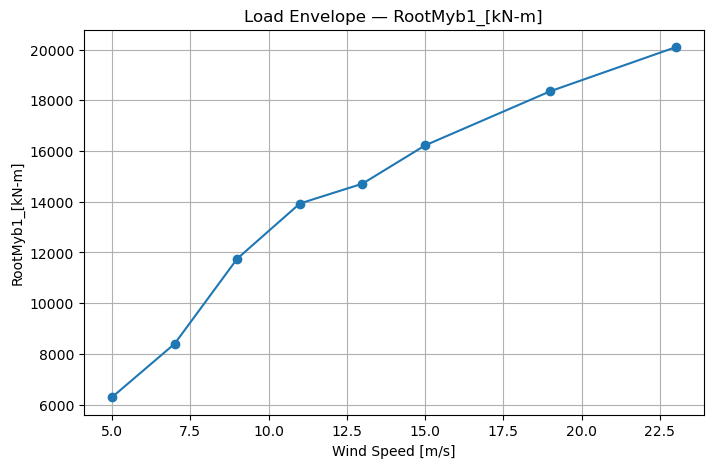

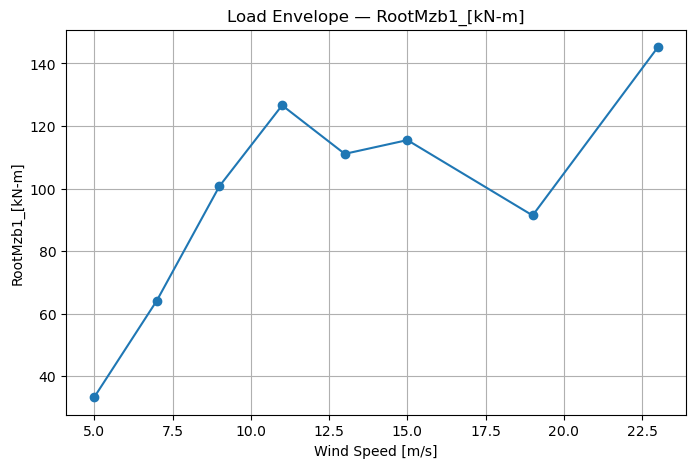

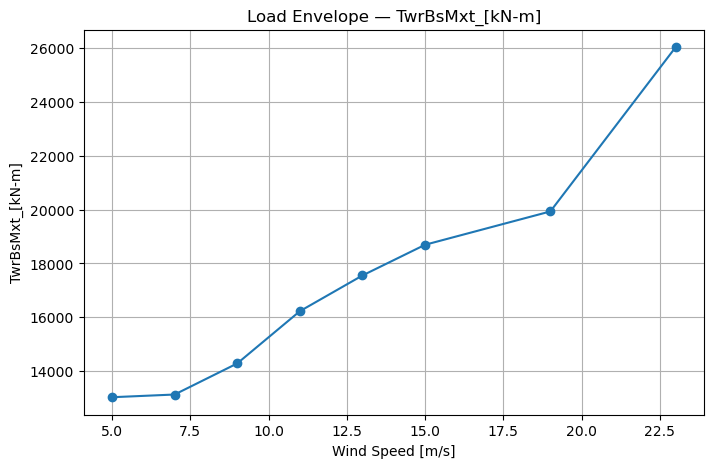

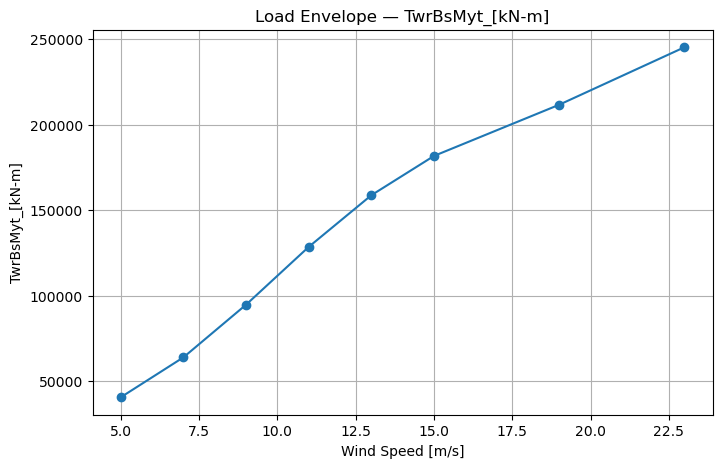

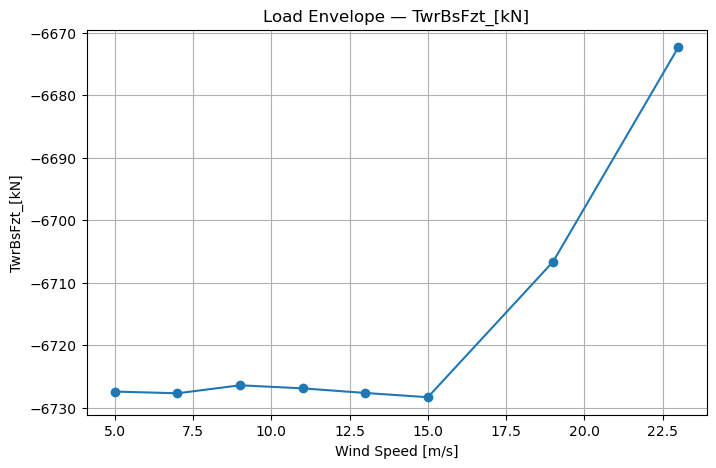

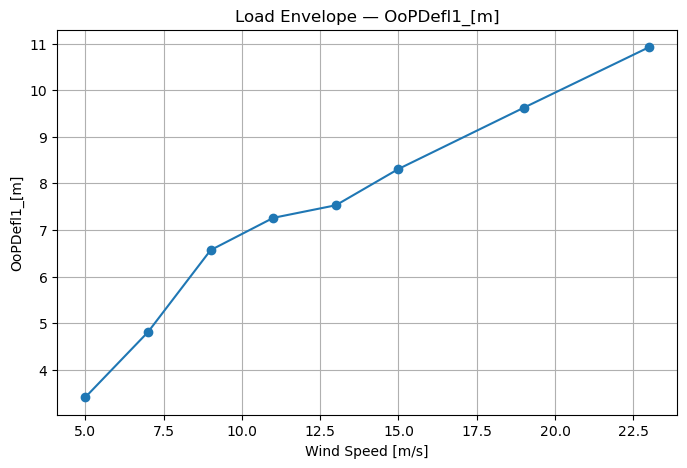

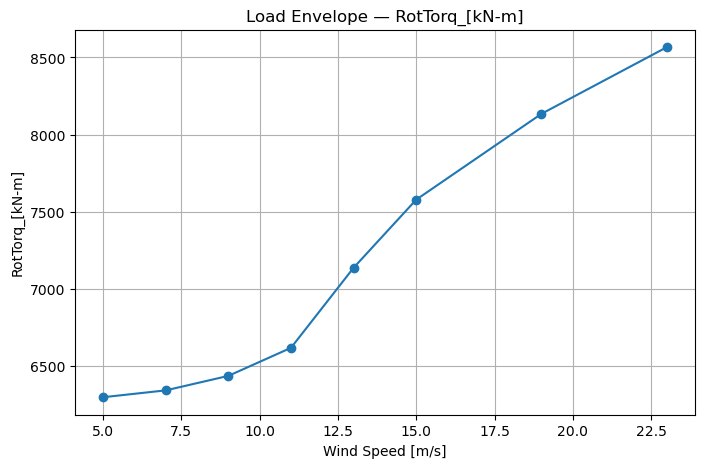

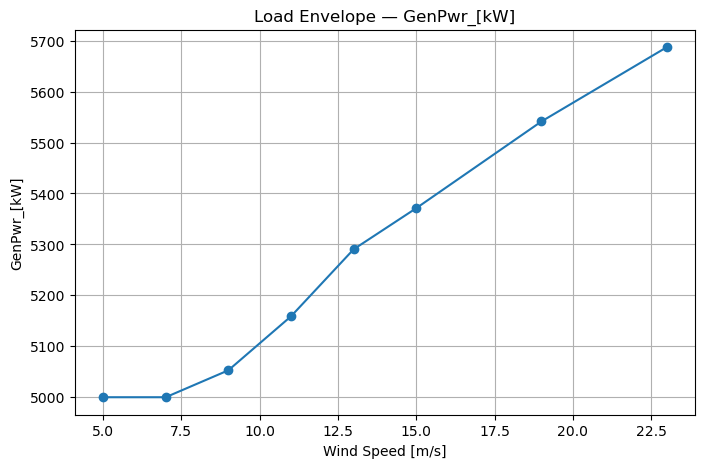

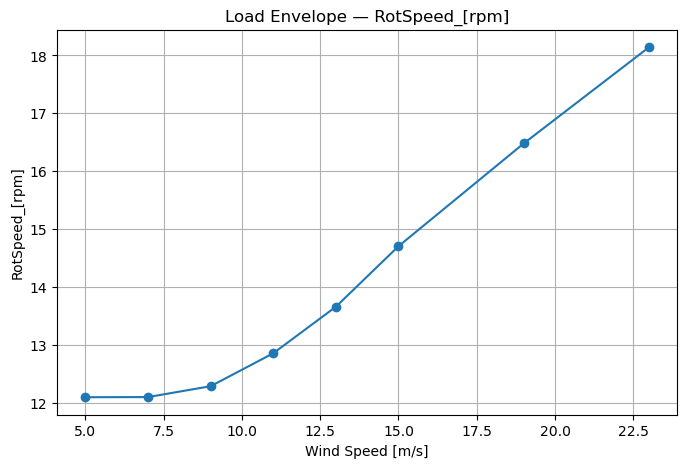

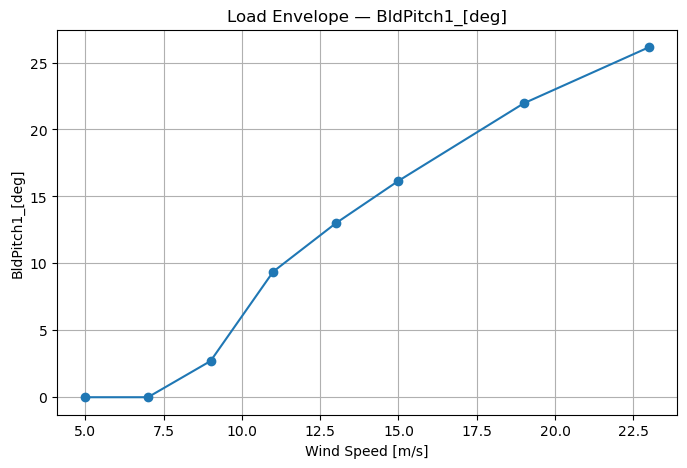

In [62]:
# ============================================================
# LOAD ENVELOPES
# ============================================================
print("Choose load channels to plot",wind_speed_max.index.to_list())

selected_channels = [
    "RootMyb1_[kN-m]",   # Blade 1 root bending moment — flapwise
    "RootMzb1_[kN-m]",   # Blade 1 root bending moment — edgewise
    "TwrBsMxt_[kN-m]",   # Tower-base bending moment — fore-aft
    "TwrBsMyt_[kN-m]",   # Tower-base bending moment — side-to-side
    "TwrBsFzt_[kN]",     # Tower-base axial force
    "OoPDefl1_[m]",      # Blade 1 out-of-plane deflection
    "RotTorq_[kN-m]",    # Rotor torque
    "GenPwr_[kW]",       # Generator power
    "RotSpeed_[rpm]",    # Rotor rotational speed
    "BldPitch1_[deg]",   # Blade 1 pitch angle
]

# Extract wind speeds from column names
wind_speeds = (
    wind_speed_max.columns
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

# Plot each selected channel
for channel in selected_channels:

    loads = wind_speed_max.loc[channel]

    plt.figure(figsize=(8, 5))

    plt.plot(
        wind_speeds,
        loads,
        marker="o"
    )

    plt.xlabel("Wind Speed [m/s]")
    plt.ylabel(channel)
    plt.title(f"Load Envelope — {channel}")
    plt.grid(True)

    plt.show()

## 6. Statistical Extreme-Load Analysis

Calculate the mean and standard deviation of case maxima at each wind speed and estimate statistical extremes using the **mean + 2σ rule**.

> **DLC 1.1 Statistical Treatment:** Statistical extreme = Mean + 2 × Standard Deviation (σ).



In [64]:
# ============================================================
# STATISTICAL EXTREME-LOAD ANALYSIS
# ============================================================

# Convert case maxima into:
# Rows    → channels
# Columns → simulation cases
# Values  → maximum load of each case

wind_speed_max = max_df.T.groupby(all_names).max().T

# Mean of case maxima at each wind speed
wind_speed_mean = (
    max_df.T
    .groupby(all_names)
    .mean()
    .T
)

# Standard deviation of case maxima at each wind speed
wind_speed_std = (
    max_df.T
    .groupby(all_names)
    .std()
    .T
)

# Simple statistical extreme: Mean + 2σ
wind_speed_stat_extreme = (
    wind_speed_mean + 2 * wind_speed_std
)
wind_speed_stat_extreme = wind_speed_stat_extreme.loc[selected_channels]

print("\nStatistical extreme-load matrix:")
wind_speed_stat_extreme


Statistical extreme-load matrix:


,WS05,WS07,WS09,WS11,WS13,WS15,WS19,WS23
RootMyb1_[kN-m],6962.366877,8941.101699,12416.929867,14101.892914,14746.397625,16320.568313,18890.830961,20796.513709
RootMzb1_[kN-m],37.003632,70.151960,109.917037,127.000505,115.826760,126.759454,109.383057,153.255759
TwrBsMxt_[kN-m],13280.965387,13308.593245,14927.177332,17316.704415,18767.167073,19894.764646,21020.136932,26798.125873
TwrBsMyt_[kN-m],42929.692451,69293.631906,102993.123947,136828.976552,168781.970101,190385.480797,218150.257738,254532.384403
TwrBsFzt_[kN],-6727.243762,-6726.442332,-6721.975403,-6722.784354,-6725.670783,-6726.835168,-6695.311909,-6657.948319
OoPDefl1_[m],3.696197,5.094069,6.919359,7.425015,7.620998,8.358570,9.880545,11.282645
RotTorq_[kN-m],6302.366568,6376.557272,6490.533731,6652.064813,7243.588669,7748.441590,8287.103349,8749.657139
GenPwr_[kW],5000.000000,5000.000000,5081.451641,5195.073095,5330.336202,5411.076411,5587.872604,5744.084380
RotSpeed_[rpm],12.101436,12.105461,12.381477,12.944666,13.915183,15.176917,16.956495,18.715496
BldPitch1_[deg],0.000000,0.000000,4.027195,9.589049,13.170354,16.243168,22.132488,26.553707


## 7. Compare Simulated and Statistical Load Envelopes

Compare the maximum simulated loads with the **DLC 1.1 statistical extreme (Mean + 2σ)** across wind speeds.


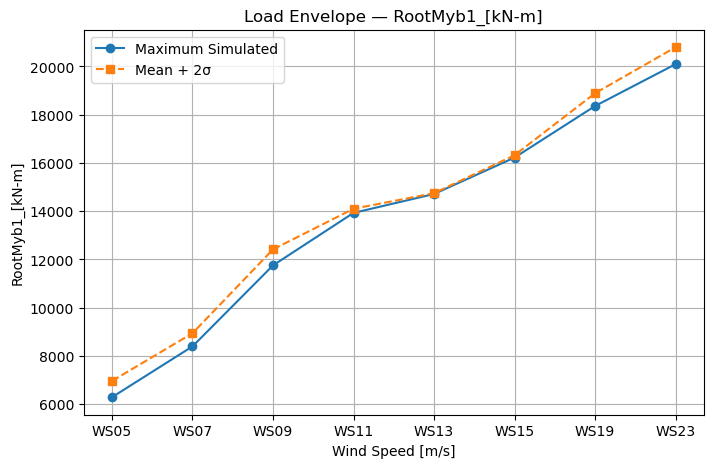

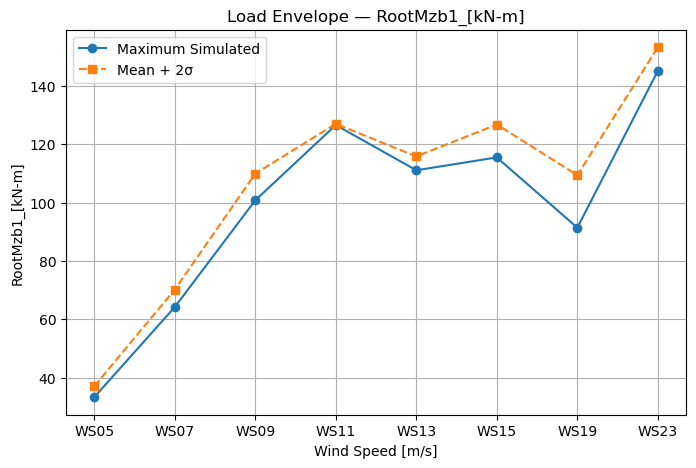

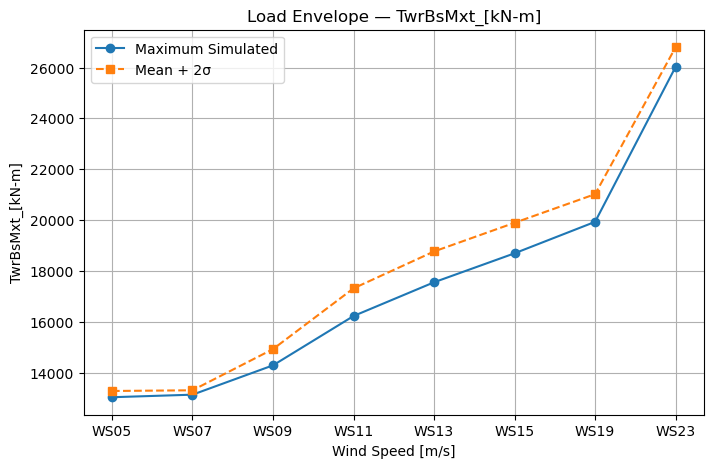

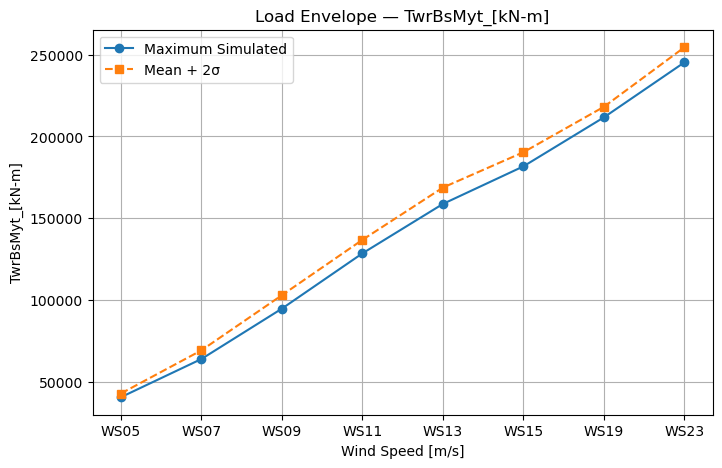

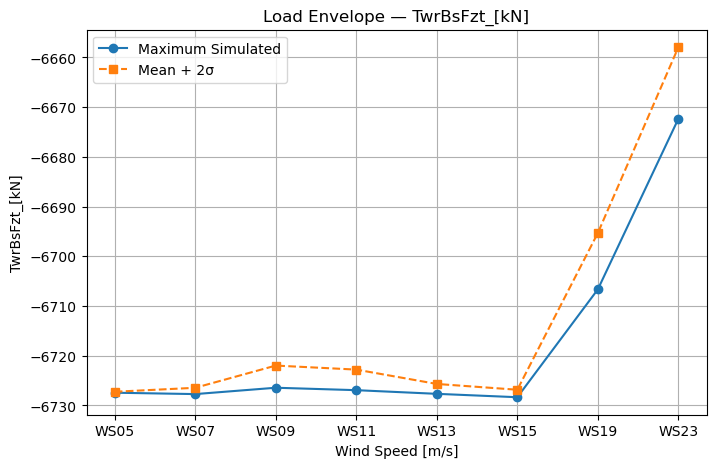

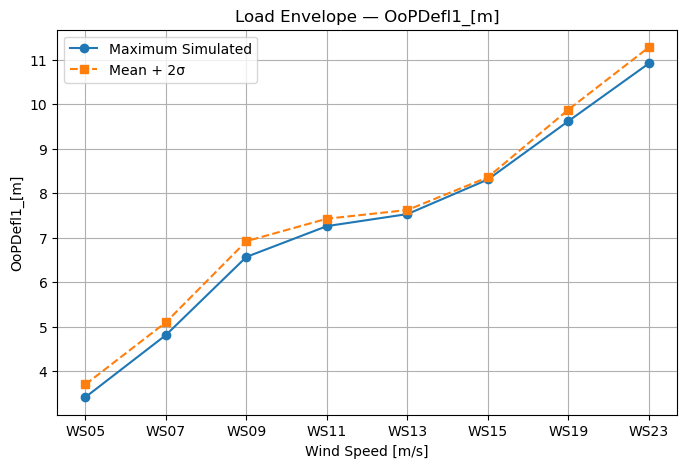

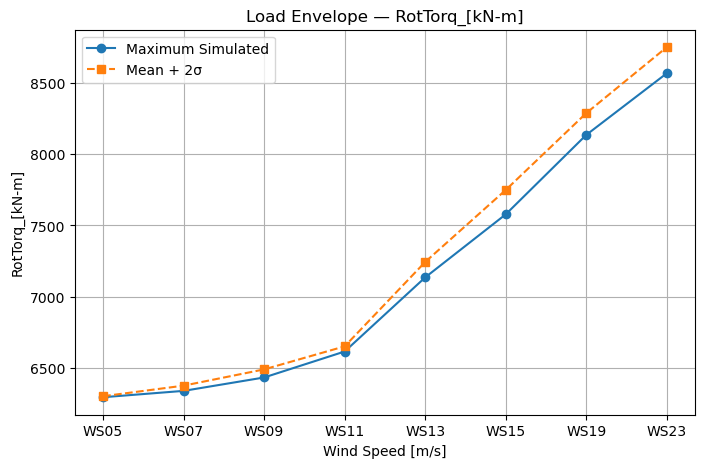

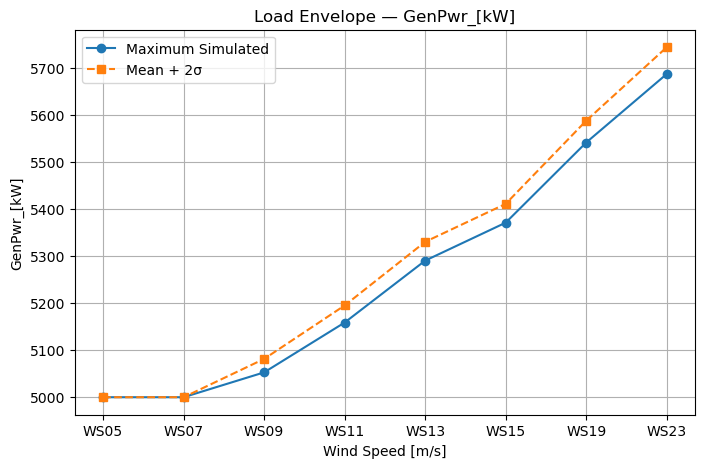

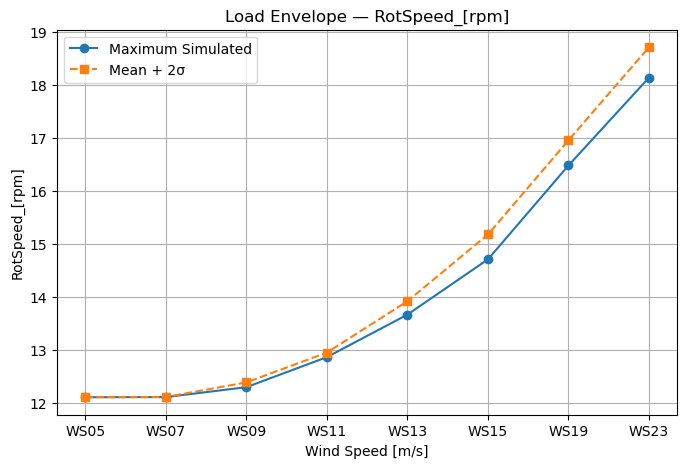

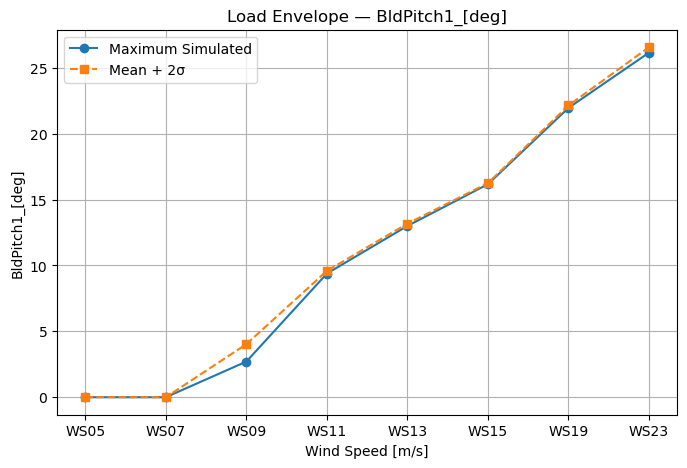

In [65]:
# ============================================================
# COMPARISON: MAXIMUM vs STATISTICAL EXTREME
# ============================================================

for channel in selected_channels:

    max_loads = wind_speed_max.loc[channel]
    stat_loads = wind_speed_stat_extreme.loc[channel]

    plt.figure(figsize=(8, 5))

    plt.plot(
        max_loads.index,
        max_loads.values,
        marker="o",
        label="Maximum Simulated"
    )

    plt.plot(
        stat_loads.index,
        stat_loads.values,
        marker="s",
        linestyle="--",
        label="Mean + 2σ"
    )

    plt.xlabel("Wind Speed [m/s]")
    plt.ylabel(channel)
    plt.title(f"Load Envelope — {channel}")
    plt.grid(True)
    plt.legend()
